# 90819-Python Final Project: Effect of Proximity to Polluters on Home Values and Vacancy Rates
Pittsburgh consistently ranks as one of the worst polluted areas in the United States. Allegheny county in particular, ranks as one of the worst, ranking 23 in the US in 2026 (https://www.lung.org/research/sota/key-findings/most-polluted-places). Industrial polluters can cause major adverse health effects due to the release of harmful particles into the air, such as benzene, lead and lead compounds, mercury and mercury compounds, methanol, and nitrates. We want to see if proximity to industrial polluters have any affect on where people choose to live. We proxy this by home values and vacancy rates.

Our primary research question is as follows: 
#### *How does proximity to major industrial polluters shape home values, vacancy, and housing distress in Mon Valley municipalities, compared with the rest of Allegheny County?*

## Analysis Organization
We organize our analysis into XX key sections:
1. Import Data
    - Our primary data comes from four sources: The US ACS 2020-2024 5-year survey data at the census tract level, Allegheny County Property Assessments data at the parcel level, EPA Toxic Release Inventory (TRI) data, and EPA Risk Screening Environmental Indicators (RSEI) data. We also use Allegheny County municipalities boundaries as a way to group our parcels.
2. Exploratory data analysis
    - Bar charts, histograms, density plots, and maps exploring the data for trends.
3. Regression Analysis
    - We will estimate two pairs of regression models. The first pair will be modeling the effect of proximity to industrial polluters on property sale prices for residential properties. The second pair with be the effect proximity of industrial polluters on vacancy rates. Each pair will include a simple OLS regression and a one that sets a dummy for whether or not a property is located in Mon Valley.
4. Conclusions, Limitations, and Areas for Further Study

### Import Libraries and Load Libraries

In [90]:
# note, you may need to install these libraries first
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pytidycensus as tc
# import mapclassify as mc
from pathlib import Path
from patsy import dmatrices
#from sklearn.linear_model import LinearRegression
import pyfixest as pf
import statsmodels.api as sm
from pathlib import Path

## 1.Load the Data
The dataframe after all of the data are cleaned and merged contains 585,005 rows and 52 columns. This main dataframe is too large to add to github (over 1 gb). The data can be shared via google drive. The exploratory analysis is still below. 

The subset used for final analysis and regression contains 24,139 rows and 52 columns. The regressions will be run on this final dataset.

In [4]:
output_dir = Path(r"C:\Users\Bryce\Main\CMU\Fall 2026\Python II\Final Project")
# load full dataframe
property_gdf = gpd.read_file(output_dir / "90819_analysis_data_full.geojson")

# load final analysis dataset 
analysis_gdf = gpd.read_file(output_dir / "90819_analysis_data.geojson")

In [36]:
# create dummy variable for Mon Valley Municipalities
monvalley_municipalities = [
    "FORWARD",
    "ELIZABETH",
    "WEST ELIZABETH",
    "JEFFERSON HILLS",
    "CLAIRTON",
    "LINCOLN",
    "LIBERTY",
    "GLASSPORT",
    "PORT VUE",
    "MCKEESPORT",
    "WEST MIFFLIN",
    "DRAVOSBURG",
    "DUQUENSNE",
    "NORTH VERSAILLES",
    "EAST PITTSBURGH",
    "NORTH BRADDOCK",
    "BRADDOCK",
    "WHITAKER",
    "MUNHALL",
    "WEST HOMESTEAD",
    "HOMESTEAD",
    "RANKIN",
    "SWISSVALE"
] 

property_gdf["mon_valley"] = property_gdf["name"].isin(monvalley_municipalities)
analysis_gdf["mon_valley"] = analysis_gdf["name"].isin(monvalley_municipalities)

## 2. Exploratory Analysis
We will start by looking at the property assessor data.

Top 3 parcel uses by class: 
1. RESIDENTIAL (523754)
2. COMMERCIAL (35870)
3. GOVERNMENT (16881)
Top 3 parcel uses by class in 2024: 
1. RESIDENTIAL (24161)
2. COMMERCIAL (1419)
3. INDUSTRIAL (142)


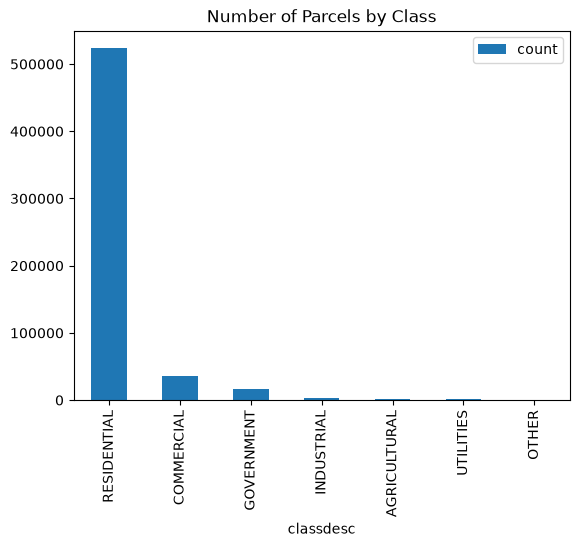

In [41]:
# get number of buildings by class
buildings_by_class = (property_gdf
                      .groupby("classdesc")
                      .size()
                      .reset_index(name="count")
                      .sort_values(by="count", ascending=False)
                      )

buildings_by_class.plot.bar(x="classdesc", y="count", title="Number of Parcels by Class")

print(f"Top 3 parcel uses by class: \n1. {buildings_by_class.iloc[0]['classdesc']} ({buildings_by_class.iloc[0]['count']})\n2. {buildings_by_class.iloc[1]['classdesc']} ({buildings_by_class.iloc[1]['count']})\n3. {buildings_by_class.iloc[2]['classdesc']} ({buildings_by_class.iloc[2]['count']})")

# filter to the year 2024 and check again
assessment_parcel_2024_df = property_gdf[property_gdf["sale_year"]==2024]
buildings_by_class_2024 = (assessment_parcel_2024_df
                           .groupby("classdesc")
                           .size()
                           .reset_index(name="count")
                           .sort_values(by="count", ascending=False))

print(f"Top 3 parcel uses by class in 2024: \n1. {buildings_by_class_2024.iloc[0]['classdesc']} ({buildings_by_class_2024.iloc[0]['count']})\n2. {buildings_by_class_2024.iloc[1]['classdesc']} ({buildings_by_class_2024.iloc[1]['count']})\n3. {buildings_by_class_2024.iloc[2]['classdesc']} ({buildings_by_class_2024.iloc[2]['count']})")
# print("We want to focus on residential properties for this analysis.")

Most parcels are residential, which is perfect for our study because even when we filter to the dataset to just one year, we still get a significant number of residential parcels.

,saleprice
min,0.00
max,14466000.00
mean,220892.47
median,150000.00


<Axes: >

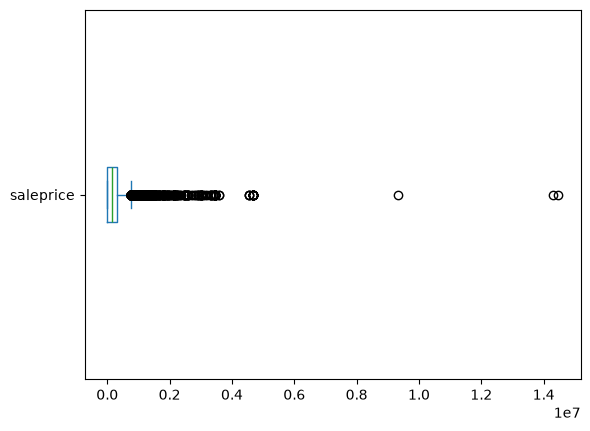

In [42]:
# Median residential sale value in 2024
summary_residential_sale_value_2024 = (assessment_parcel_2024_df[assessment_parcel_2024_df["classdesc"]=="RESIDENTIAL"]
                                      .agg({"saleprice":["min","max","mean","median"]})
                                      .round(2)
                                      )
display(summary_residential_sale_value_2024)

assessment_parcel_2024_df[assessment_parcel_2024_df["classdesc"]=="RESIDENTIAL"]["saleprice"].plot.box(vert=False)

# create a boxplot of the residential sale values in 2024
# plt.figure(figsize=(10,6))
# plt.boxplot(assessment_parcel_2024_df[assessment_parcel_2024_df["classdesc"]=="RESIDENTIAL"]["saleprice"], vert=False)
# plt.title("Boxplot of Residential Sale Values in 2024")
# plt.xlabel("Sale Price")
# plt.show()

The median sale price for residential parcels is $150,000 and the mean sale price is $220,892, indicating that the data has a right skew. The maximum sale price $14.466 million. This is a very high outlier, but there are a number of other outliers with properties sold over around $5 and $10 million. The minimum sale value is $0. $0 sales often mean homes were passed down or given away without sale, or foreclosed on. Major outliers and $0 sales should be removed from the dataset.

In [50]:
assessment_parcel_2024_df_subset = assessment_parcel_2024_df[(assessment_parcel_2024_df["classdesc"]=="RESIDENTIAL") & 
                                                                        (assessment_parcel_2024_df["saleprice"]>0) &
                                                                        (assessment_parcel_2024_df["saleprice"]<assessment_parcel_2024_df["saleprice"].quantile(0.99))]

print(assessment_parcel_2024_df_subset.shape)

# summary of sale prices for residential properties in 2024 with 0s removed
summary_residential_sale_value_2024_subset = (assessment_parcel_2024_df_subset
                                      .filter(items=["saleprice"])
                                      .describe()
                                      .round(2)
                                      )

display(summary_residential_sale_value_2024_subset)

(23364, 53)


,saleprice
count,23364.00
mean,207498.67
std,243727.86
min,1.00
25%,10.00
50%,157500.00
75%,300000.00
max,2000000.00


When subsetting the data by removing $0 sales at setting the max to less than the 99th percentile sale value, the median increases to $157,500 and the mean decreases slightly to $207,498. The number of rows drops by 797 to 23,364.

Next we will look at land, building, and total county and fair market values.

In [49]:
# Summary residential sale value in 2024
residential_property_value_2024_summary = (assessment_parcel_2024_df_subset
                                           .filter(items=["countybuilding",
                                                          "countyland",
                                                          "countytotal",
                                                          "fairmarketbuilding",
                                                          "fairmarketland",
                                                          "fairmarkettotal"])
                                           .describe()
                                           .round(2))
residential_property_value_2024_summary

,countybuilding,countyland,countytotal,fairmarketbuilding,fairmarketland,fairmarkettotal
count,23364.00,23364.00,23364.00,23364.00,23364.00,23364.00
mean,98864.94,30880.67,129745.60,106563.46,31069.60,137633.05
std,113665.97,31925.95,134680.65,115751.10,32294.83,137349.64
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,32200.00,11500.00,48400.00,37900.00,11700.00,53900.00
50%,68200.00,23800.00,95800.00,77000.00,23900.00,104900.00
75%,127325.00,41600.00,166400.00,137500.00,41900.00,177500.00
max,4003800.00,1050000.00,4250000.00,4003800.00,1050000.00,4250000.00


Next, we want to check how many residential properties are in Mon Valley Municipalities. There are 2,800 parcels within Mon Valley and 20,564 outside of Mon Valley.

In [73]:
assessment_parcel_2024_df_subset.groupby("mon_valley").size().reset_index(name="count")

,mon_valley,count
0,False,20564
1,True,2800


The average sale price and parcel value is higher outside of Mon Valley than within Mon Valley.

In [74]:
# summary stats of properties in Mon Valley vs not in Mon Valley
assessment_by_dummies_subset = (assessment_parcel_2024_df_subset
                                .filter(items=["mon_valley",
                                                "saleprice",
                                                "countybuilding",
                                                "countyland",
                                                "countytotal",
                                                "fairmarketbuilding",
                                                "fairmarketland",
                                                "fairmarkettotal"])
                                .groupby("mon_valley")
                                .mean()
                                .round(2))
assessment_by_dummies_subset


,saleprice,countybuilding,countyland,countytotal,fairmarketbuilding,fairmarketland,fairmarkettotal
mon_valley,,,,,,,
False,218594.08,105600.69,32994.04,138594.73,113509.83,33181.53,146691.36
True,126010.85,49395.64,15359.46,64755.10,55547.32,15558.96,71106.28


## 3. Regression Model
We will model two primary regressions:
- Residential parcel values (sale prices) by average distance to a polluter
    - Covariates will include median household income, vacancy rates, share white, college educated share, dwelling grade, and dummy for being located in Mon Valley
    - Null hypothesis: proximity to major industrial polluters has no effect on home values
- Census tract level vacancy rates by average distance to a polluter
    - Covariates will include median home value, share white, college educated share, and dummy for being located in Mon Valley
    - Null hypothesis: proximity to major industrial polluters has no effect on vacancy rates

Our first model is as follows:
$$
\text{ResidentialSalePrice}_{i} = \beta_0
+
\beta_1 \,\text{DistanceToEmitter}_{i}
+
\beta_2 \,\text{MedianHouseholdIncome}_{i}
+
\beta_3 \,\text{VacancyRate}_{i}
+
\beta_4 \,\text{ShareWhite}_{i}
+
\beta_5 \,\text{ShareCollegeEducated}_{i}
+
\beta_6 \,\text{MonValley_Dummy}_{i}
+
\varepsilon_i
$$

And model two is: 
$$
\text{Vacancy Rate}_{i} = \beta_0
+
\beta_1 \,\text{DistanceToEmitter}_{i}
+
\beta_2 \,\text{MedianHomeValue}_{i}
+
\beta_3 \,\text{ShareWhite}_{i}
+
\beta_4 \,\text{ShareCollegeEducated}_{i}
+
\beta_5 \,\text{MonValley_Dummy}_{i}
+
\varepsilon_i
$$

Because the models come in pairs, the residential parcel sale values and vacancy rate models will be modified to add an interaction variable that indicates if these variables are in Mon Valley or not.

We will start with the OLS regression on residential parcel sale values along with the model with the Mon Valley interaction term.

In [80]:
# Subset analysis_gdf to remove outlier sale prices
analysis_gdf_no_outliers = analysis_gdf[
    (analysis_gdf["saleprice"] < analysis_gdf["saleprice"].quantile(0.99)) &
    (analysis_gdf["saleprice"] > 0)
    ]

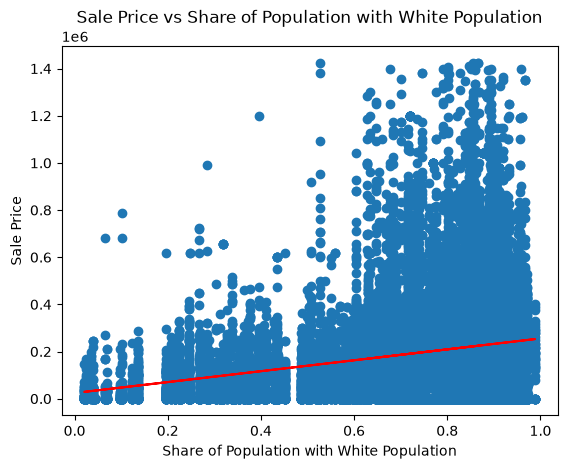

In [112]:
# view trends in data
plt.scatter(model_data["pop_white_share"], model_data["saleprice"])
x = model_data["pop_white_share"]
y = model_data["saleprice"]

coeffs = np.polyfit(x, y, 1)
plt.plot(x, np.polyval(coeffs, x), color="red")
plt.xlabel("Share of Population with White Population")
plt.ylabel("Sale Price")
plt.title("Sale Price vs Share of Population with White Population")
plt.show()

### Model 1: OLS Regression on Sale Prices with and without Mon Valley Interaction

In [122]:
feature_cols = ["exp_log_l1", "vacancy_rate" ,"hhinc", "pop_white_share", "college_degree_share"]
model_data = analysis_gdf_no_outliers.loc[analysis_gdf_no_outliers["pop_total"] > 0, ["saleprice", "tractfips", "mon_valley", *feature_cols]].apply(pd.to_numeric, errors="coerce").dropna()

fe_model = pf.feols("saleprice ~ exp_log_l1 + mon_valley + vacancy_rate + hhinc + pop_white_share + college_degree_share", data=model_data, vcov="HC1")

# fe_model.coef()
# fe_model.se()
# fe_model.tidy()

# model with interaction term between exp_log_l1 and mon_valley
fe_model2 = pf.feols("saleprice ~ exp_log_l1 + mon_valley + vacancy_rate + hhinc + pop_white_share + college_degree_share + exp_log_l1:mon_valley", data=model_data, vcov="HC1")


In [136]:
pf.etable(
    [fe_model, fe_model2],
    labels={
        "exp_log_l1": "Weighted Distance from Emitters (L1)",
        "mon_valley": "Mon Valley Dummy",
        "vacancy_rate": "Vacancy Rate",
        "hhinc": "Median Household Income",
        "pop_white_share": "Share of White Population",
        "college_degree_share": "Share of Population with College Degree",
        "exp_log_l1:mon_valley": "L1 x Mon Valley Dummy"
    },
    caption="Residential Property Sale Value: Naive OLS vs Interaction"
)

GT(_tbl_data=  __index_level_0__                                  __index_level_1__  \
0              coef               Weighted Distance from Emitters (L1)   
1              coef                                   Mon Valley Dummy   
2              coef                                       Vacancy Rate   
3              coef                            Median Household Income   
4              coef                          Share of White Population   
5              coef            Share of Population with College Degree   
6              coef  Weighted Distance from Emitters (L1) × Mon Val...   
7              coef                                          Intercept   
8             stats                                       Observations   
9             stats                                                 R²   

                                0                               1  
0   -34253.433*** <br> (5467.561)   -49514.513*** <br> (9652.356)  
1         958.017 <br> (3565.370)       -5946.604 <br> (4453.397)  
2   90134.333*** <br> (23872.983)   93917.643*** <br> (23894.696)  
3           1.650*** <br> (0.076)           1.641*** <br> (0.076)  
4      -14879.374 <br> (7618.888)      -12169.210 <br> (7816.383)  
5  358173.130*** <br> (18886.759)  358321.198*** <br> (18881.371)  
6                                    29445.588** <br> (11308.418)  
7   -81584.626*** <br> (7783.721)   -82161.656*** <br> (7772.788)  
8                          23,230                          23,230  
9                           0.191                           0.191  , _body=<great_tables._gt_data.Body object at 0x0000019F4311BDE0>, _boxhead=Boxhead([ColInfo(var='__index_level_0__', type=<ColInfoTypeEnum.row_group: 3>, column_label='__index_level_0__', column_align='center', column_width=None), ColInfo(var='__index_level_1__', type=<ColInfoTypeEnum.stub: 2>, column_label='__index_level_1__', column_align='center', column_width=None), ColInfo(var='0', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='(1)'), column_align='center', column_width=None), ColInfo(var='1', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='(2)'), column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x0000019F40E28410>, _spanners=Spanners([SpannerInfo(spanner_id='saleprice', spanner_level=1, spanner_label=Html(text='saleprice'), spanner_units=None, spanner_pattern=None, vars=['0', '1'], built=None)]), _heading=Heading(title='Residential Property Sale Value: Naive OLS vs Interaction', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x0000019F40DE5250>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x0000019F40E290D0>, _source_notes=[Html(text='Significance levels: * p &lt; 0.05, ** p &lt; 0.01, *** p &lt; 0.001. Format of coefficient cell: Coefficient   (Std. Error)')], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x0000019F40DA62D0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x0000019F40E2A570>, <great_tables._gt_data.FormatInfo object at 0x0000019F40E29C70>, <great_tables._gt_data.FormatInfo object at 0x0000019F40E28AD0>, <great_tables._gt_data.FormatInfo object at 0x0000019F40E2BE90>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='

In [ ]:
# OLS Regression
feature_cols = ["exp_log_l1", "vacancy_rate" ,"hhinc", "pop_white_share", "college_degree_share"]
model_data = analysis_gdf_no_outliers.loc[analysis_gdf_no_outliers["pop_total"] > 0, ["saleprice", *feature_cols]].apply(pd.to_numeric, errors="coerce").dropna()

y, X = dmatrices("saleprice ~ exp_log_l1 + vacancy_rate + hhinc + pop_white_share + college_degree_share", data=model_data, return_type="dataframe")
model_1 = sm.OLS(y, X).fit()
print(model_1.summary())

                            OLS Regression Results                            
Dep. Variable:              saleprice   R-squared:                       0.189
Model:                            OLS   Adj. R-squared:                  0.189
Method:                 Least Squares   F-statistic:                     1080.
Date:                Sat, 10 Oct 2026   Prob (F-statistic):               0.00
Time:                        01:20:37   Log-Likelihood:            -3.1534e+05
No. Observations:               23138   AIC:                         6.307e+05
Df Residuals:                   23132   BIC:                         6.307e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept            -7.196e+04 

### Model 2: OLS Regression on Vacancy Rates with and Without Interaction

In [133]:
# OLS Regression
feature_cols_2 = ["exp_log_l1", "vacancy_rate", "hhinc", "home_val", "pop_white_share", "college_degree_share"]
model_data2 = analysis_gdf_no_outliers.loc[analysis_gdf_no_outliers["pop_total"] > 0, ["saleprice", "mon_valley", *feature_cols_2]].apply(pd.to_numeric, errors="coerce").dropna()

fe_model3 = pf.feols("vacancy_rate ~ exp_log_l1 + mon_valley + home_val + pop_white_share + college_degree_share", data=model_data2, vcov="HC1")
fe_model4 = pf.feols("vacancy_rate ~ exp_log_l1 + mon_valley + home_val + pop_white_share + college_degree_share + exp_log_l1:mon_valley", data=model_data2, vcov="HC1")



In [135]:
pf.etable(
    [fe_model3, fe_model4],
    labels={
        "exp_log_l1": "Weighted Distance from Emitters (L1)",
        "mon_valley": "Mon Valley Dummy",
        "home_val": "Median Home Value",
        "pop_white_share": "Share of White Population",
        "college_degree_share": "Share of Population with College Degree",
        "exp_log_l1:mon_valley": "L1 x Mon Valley Dummy"
    },
    caption="Vacancy Rate: Naive OLS vs Interaction"
)

GT(_tbl_data=  __index_level_0__                                  __index_level_1__  \
0              coef               Weighted Distance from Emitters (L1)   
1              coef                                   Mon Valley Dummy   
2              coef                                  Median Home Value   
3              coef                          Share of White Population   
4              coef            Share of Population with College Degree   
5              coef  Weighted Distance from Emitters (L1) × Mon Val...   
6              coef                                          Intercept   
7             stats                                       Observations   
8             stats                                                 R²   

                        0                       1  
0   0.040*** <br> (0.003)   0.081*** <br> (0.004)  
1      0.001 <br> (0.001)   0.019*** <br> (0.001)  
2  -0.000*** <br> (0.000)  -0.000*** <br> (0.000)  
3  -0.192*** <br> (0.002)  -0.196*** <br> (0.002)  
4  -0.037*** <br> (0.006)  -0.039*** <br> (0.006)  
5                          -0.080*** <br> (0.005)  
6   0.260*** <br> (0.002)   0.259*** <br> (0.002)  
7                  23,138                  23,138  
8                   0.408                   0.416  , _body=<great_tables._gt_data.Body object at 0x0000019F43123D90>, _boxhead=Boxhead([ColInfo(var='__index_level_0__', type=<ColInfoTypeEnum.row_group: 3>, column_label='__index_level_0__', column_align='center', column_width=None), ColInfo(var='__index_level_1__', type=<ColInfoTypeEnum.stub: 2>, column_label='__index_level_1__', column_align='center', column_width=None), ColInfo(var='0', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='(1)'), column_align='center', column_width=None), ColInfo(var='1', type=<ColInfoTypeEnum.default: 1>, column_label=Html(text='(2)'), column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x0000019F40E2A7B0>, _spanners=Spanners([SpannerInfo(spanner_id='vacancy_rate', spanner_level=1, spanner_label=Html(text='vacancy_rate'), spanner_units=None, spanner_pattern=None, vars=['0', '1'], built=None)]), _heading=Heading(title='Vacancy Rate: Naive OLS vs Interaction', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x0000019F40DE5EB0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x0000019F40E29070>, _source_notes=[Html(text='Significance levels: * p &lt; 0.05, ** p &lt; 0.01, *** p &lt; 0.001. Format of coefficient cell: Coefficient   (Std. Error)')], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x0000019F40DA6090>, _formats=[<great_tables._gt_data.FormatInfo object at 0x0000019F40E2A630>, <great_tables._gt_data.FormatInfo object at 0x0000019F40E2A1B0>, <great_tables._gt_data.FormatInfo object at 0x0000019F40E2BB30>, <great_tables._gt_data.FormatInfo object at 0x0000019F40E2B0B0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='t

## Conclusions, Limitations, and Areas for Further Study